In [ ]:
import os, sys, io, json, time, math, re, subprocess, warnings
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")
os.environ.setdefault("USE_TORCH", "1")


def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)


try:
    import doctr
except ImportError:
    print(">> Installing python-doctr (this takes ~1-2 min on Colab)...")

    _pip("python-doctr[viz]")

try:
    import reportlab
except ImportError:
    _pip("reportlab")

import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Rectangle, Polygon as MplPolygon
from PIL import Image, ImageDraw, ImageFont

import doctr
from doctr.io import DocumentFile
from doctr.models import (
    ocr_predictor,
    kie_predictor,
    detection_predictor,
    recognition_predictor,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 78)
print(f"docTR      : {doctr.__version__}")
print(f"torch      : {torch.__version__}")
print(f"device     : {DEVICE}"
      + (f"  ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))
print(f"python     : {sys.version.split()[0]}")
print("=" * 78)
print("NOTE: if the import above failed, restart the runtime "
      "(Runtime > Restart session) and re-run this cell.\n")


CFG = dict(
    RUN_BENCHMARK   = True,
    RUN_SECOND_PASS = True,
    RUN_ROTATION    = True,
    RUN_LAYOUT      = True,
    RUN_KIE         = True,
    RUN_SYNTHESIS   = True,
    RUN_PDF_EXPORT  = True,
)

WORK = "/content/doctr_demo" if os.path.isdir("/content") else "./doctr_demo"
os.makedirs(WORK, exist_ok=True)
print(f"working dir: {WORK}\n")


_FONT = font_manager.findfont(font_manager.FontProperties(family="DejaVu Sans"))
_FONT_B = font_manager.findfont(
    font_manager.FontProperties(family="DejaVu Sans", weight="bold"))

A4 = (1240, 1754)

INVOICE_LINES = [

    ( 80,  70, "NORTHWIND TRADING CO.",                    38, True ),
    ( 80, 122, "42 Harbour Road, Bristol BS1 5TY",         22, False),
    ( 80, 152, "VAT GB 884 5521 09",                       22, False),
    (820,  70, "INVOICE",                                  44, True ),
    (820, 132, "Invoice No: INV-2024-00817",               22, False),
    (820, 162, "Date: 14/03/2024",                         22, False),
    (820, 192, "Due Date: 13/04/2024",                     22, False),
    ( 80, 260, "BILL TO",                                  24, True ),
    ( 80, 296, "Aurora Robotics Ltd",                      24, False),
    ( 80, 328, "Unit 7 Fenway Business Park",              22, False),
    ( 80, 358, "Cambridge CB4 0WS",                        22, False),
    ( 80, 388, "Contact: procurement@aurorarobotics.co.uk",22, False),

    ( 80, 470, "DESCRIPTION",                              24, True ),
    (640, 470, "QTY",                                      24, True ),
    (780, 470, "UNIT PRICE",                               24, True ),
    (1010,470, "AMOUNT",                                   24, True ),

    ( 80, 520, "Servo controller board Rev C",             22, False),
    (640, 520, "12",                                       22, False),
    (780, 520, "84.50",                                    22, False),
    (1010,520, "1014.00",                                  22, False),
    ( 80, 560, "Harmonic drive gearbox 50:1",              22, False),
    (640, 560, "4",                                        22, False),
    (780, 560, "312.75",                                   22, False),
    (1010,560, "1251.00",                                  22, False),
    ( 80, 600, "Shielded encoder cable 2m",                22, False),
    (640, 600, "20",                                       22, False),
    (780, 600, "11.40",                                    22, False),
    (1010,600, "228.00",                                   22, False),
    ( 80, 640, "Calibration service on-site",              22, False),
    (640, 640, "1",                                        22, False),
    (780, 640, "450.00",                                   22, False),
    (1010,640, "450.00",                                   22, False),

    (780, 720, "Subtotal",                                 22, False),
    (1010,720, "2943.00",                                  22, False),
    (780, 756, "VAT 20%",                                  22, False),
    (1010,756, "588.60",                                   22, False),
    (780, 796, "TOTAL DUE",                                26, True ),
    (1010,796, "3531.60",                                  26, True ),

    ( 80, 900, "PAYMENT TERMS",                            24, True ),
    ( 80, 936, "Net 30 days. Late payments accrue interest at 2% per month.", 20, False),
    ( 80, 968, "Bank: Lloyds  Sort Code: 30-96-26  Account: 41775302",       20, False),
    ( 80,1010, "Reference: INV-2024-00817",                20, False),
]

PAGE2_LINES = [
    ( 80,  70, "APPENDIX A - DELIVERY SCHEDULE",           34, True ),
    ( 80, 140, "All shipments leave the Bristol warehouse before 16:00 GMT.", 22, False),
    ( 80, 176, "Tracking numbers are emailed on the day of dispatch.",       22, False),
    ( 80, 240, "MILESTONE",                                24, True ),
    (700, 240, "TARGET DATE",                              24, True ),
    ( 80, 288, "Purchase order acknowledged",              22, False),
    (700, 288, "18/03/2024",                               22, False),
    ( 80, 328, "Controller boards shipped",                22, False),
    (700, 328, "25/03/2024",                               22, False),
    ( 80, 368, "Gearboxes shipped",                        22, False),
    (700, 368, "02/04/2024",                               22, False),
    ( 80, 408, "On-site calibration window",               22, False),
    (700, 408, "08/04/2024",                               22, False),
    ( 80, 480, "Questions? Call +44 117 496 0022 or email ops@northwind.example", 20, False),
]


def render_page(lines, size=A4, bg=250):
    """Draw a clean document page from a list of (x, y, text, size, bold)."""
    img = Image.new("RGB", size, (bg, bg, bg))
    d = ImageDraw.Draw(img)
    for x, y, text, sz, bold in lines:
        font = ImageFont.truetype(_FONT_B if bold else _FONT, sz)
        d.text((x, y), text, fill=(18, 18, 22), font=font)

    d.line([(80, 455), (1160, 455)], fill=(60, 60, 60), width=2)
    d.line([(80, 505), (1160, 505)], fill=(160, 160, 160), width=1)
    d.line([(760, 700), (1160, 700)], fill=(60, 60, 60), width=2)
    return img


def scanify(img, angle=0.0, noise=6.0, jpeg_quality=72, blur_shadow=True):
    """Degrade a clean render so it behaves like a phone photo / flatbed scan."""
    if angle:
        img = img.rotate(angle, expand=True, resample=Image.BICUBIC,
                         fillcolor=(250, 250, 250))
    arr = np.asarray(img).astype(np.float32)
    if blur_shadow:
        h, w = arr.shape[:2]
        gx = np.linspace(-1, 1, w)[None, :]
        gy = np.linspace(-1, 1, h)[:, None]
        shade = 1.0 - 0.10 * (gx ** 2 + 0.6 * gy ** 2)
        arr *= shade[..., None]
    if noise:
        arr += np.random.normal(0, noise, arr.shape)
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    out = Image.fromarray(arr)
    if jpeg_quality:
        buf = io.BytesIO()
        out.save(buf, format="JPEG", quality=jpeg_quality)
        buf.seek(0)
        out = Image.open(buf).convert("RGB")
    return out


clean1 = render_page(INVOICE_LINES)
clean2 = render_page(PAGE2_LINES)

page1_path   = os.path.join(WORK, "invoice_p1.png")
page2_path   = os.path.join(WORK, "invoice_p2.png")
rotated_path = os.path.join(WORK, "invoice_rotated.png")
pdf_path     = os.path.join(WORK, "invoice.pdf")

scanify(clean1, angle=0.4).save(page1_path)
scanify(clean2, angle=-0.3).save(page2_path)
scanify(clean1, angle=13.0, noise=8.0).save(rotated_path)
clean1.save(pdf_path, save_all=True, append_images=[clean2], resolution=150)


GT_WORDS_P1 = [w for _, _, t, _, _ in INVOICE_LINES for w in t.split()]
print(f"generated: {page1_path}, {page2_path}, {rotated_path}, {pdf_path}")
print(f"ground-truth words on page 1: {len(GT_WORDS_P1)}\n")

fig, ax = plt.subplots(1, 3, figsize=(15, 7))
for a, im, t in zip(ax, [Image.open(page1_path), Image.open(page2_path),
                         Image.open(rotated_path)],
                    ["page 1 (scanified)", "page 2", "rotated 13 deg"]):
    a.imshow(im); a.set_title(t, fontsize=10); a.axis("off")
plt.tight_layout(); plt.show()


imgs_doc  = DocumentFile.from_images([page1_path, page2_path])
pdf_doc   = DocumentFile.from_pdf(pdf_path)
pdf_hi    = DocumentFile.from_pdf(pdf_path, scale=3)
rot_doc   = DocumentFile.from_images(rotated_path)

print("from_images :", [p.shape for p in imgs_doc], imgs_doc[0].dtype)
print("from_pdf    :", [p.shape for p in pdf_doc])
print("from_pdf x3 :", [p.shape for p in pdf_hi])
print("""
Rules of thumb for `scale`:
  * body text should be >= ~10 px tall for the recognition model to be happy
  * scale=2 (default) suits 150-300 dpi scans; bump to 3-4 for dense 8pt text
  * you can also pass raw numpy arrays straight to any predictor:
        predictor([np.asarray(pil_image)])
  * DocumentFile.from_url(...) exists too, but needs the [html] extra
""")


def build_ocr(det="db_resnet50", reco="crnn_vgg16_bn", **kw):
    """Construct an OCR predictor and move it to the GPU when there is one."""
    model = ocr_predictor(det_arch=det, reco_arch=reco, pretrained=True, **kw)
    if DEVICE == "cuda":
        try:
            model = model.cuda()
        except Exception as e:
            print(f"  (cuda placement skipped: {e})")
    return model


def timeit(fn, *args, warmup=1, runs=3, **kw):
    """Warm up (weight load / cudnn autotune / lazy init), then time properly."""
    for _ in range(warmup):
        fn(*args, **kw)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    out = None
    for _ in range(runs):
        out = fn(*args, **kw)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    return out, (time.perf_counter() - t0) / runs


predictor = build_ocr()
result, dt = timeit(predictor, imgs_doc, runs=2)
print(f"\nbaseline end-to-end: {dt:.2f}s for {len(imgs_doc)} pages "
      f"({dt/len(imgs_doc):.2f}s/page on {DEVICE})")
print(f"first 90 chars of page 1: {result.pages[0].render()[:90]!r}")

In [ ]:
def norm(w):
    return re.sub(r"[^\w@:./+-]", "", w.lower())


def bag_accuracy(gt_words, pred_words):
    """Order-insensitive word recall — good enough to rank models quickly."""
    g, p = Counter(map(norm, gt_words)), Counter(map(norm, pred_words))
    return sum((g & p).values()) / max(len(gt_words), 1)


def page_words(page):
    return [w.value for b in page.blocks for l in b.lines for w in l.words]


if CFG["RUN_BENCHMARK"]:
    combos = [
        ("db_mobilenet_v3_large", "crnn_mobilenet_v3_small"),
        ("fast_base",             "crnn_vgg16_bn"),
        ("db_resnet50",           "crnn_vgg16_bn"),
        ("db_resnet50",           "parseq"),
    ]
    rows = []
    for det, reco in combos:
        try:
            m = build_ocr(det, reco)
            res, dt = timeit(m, [imgs_doc[0]], warmup=1, runs=2)
            pw = page_words(res.pages[0])
            rows.append((f"{det} + {reco}", dt, len(pw), bag_accuracy(GT_WORDS_P1, pw)))
            del m
            if DEVICE == "cuda":
                torch.cuda.empty_cache()
        except Exception as e:
            rows.append((f"{det} + {reco}", float("nan"), 0, float("nan")))
            print(f"  !! {det}+{reco} failed: {e}")

    print("\n" + "-" * 78)
    print(f"{'architecture':<46}{'sec/page':>10}{'#words':>9}{'word acc':>11}")
    print("-" * 78)
    for name, dt, n, acc in rows:
        print(f"{name:<46}{dt:>10.2f}{n:>9}{acc:>10.1%}")
    print("-" * 78)
    print("""
Reading the table:
  * detection choice drives RECALL (#words found); recognition drives accuracy
  * mobilenet variants are 5-10x cheaper and lose only a couple of points on
    clean documents — they are usually the right default for bulk pipelines
  * parseq / master are worth it on noisy, handwritten or curved text only
  * these numbers are for ONE synthetic page; always benchmark on your own data
""")


page = result.pages[0]

print(f"page dimensions   : {page.dimensions}   (H, W in px)")
print(f"page orientation  : {page.orientation}")
print(f"page language     : {page.language}")
print(f"blocks/lines/words: {len(page.blocks)}, "
      f"{sum(len(b.lines) for b in page.blocks)}, {len(page_words(page))}\n")

for b_i, block in enumerate(page.blocks[:1]):
    print(f"Block {b_i}  geometry={np.round(np.array(block.geometry), 3).tolist()}")
    for l_i, line in enumerate(block.lines[:2]):
        print(f"  Line {l_i}: {' '.join(w.value for w in line.words)}")
        for w in line.words[:4]:
            geo = np.round(np.array(w.geometry), 4).tolist()
            print(f"    Word {w.value!r:<22} conf={w.confidence:.3f} "
                  f"objectness={getattr(w, 'objectness_score', None)} "
                  f"crop_orient={getattr(w, 'crop_orientation', None)}")
            print(f"      geometry={geo}")

print("""
Key facts about geometry:
  * coordinates are RELATIVE (0-1), so multiply by (W, H) to get pixels
  * assume_straight_pages=True  -> ((xmin, ymin), (xmax, ymax))
  * assume_straight_pages=False -> a 4-point polygon [(x,y) x 4], clockwise
  * confidence       = recognition softmax confidence for the whole word
  * objectness_score = how sure the DETECTOR was that this is text
    -> filter on objectness to kill hallucinated boxes, on confidence to
       flag words a human should review. They fail differently.
""")


def geom_to_pixels(geom, w, h):
    g = np.asarray(geom, dtype=np.float32)
    if g.ndim == 2 and g.shape == (2, 2):
        (x0, y0), (x1, y1) = g
        return np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]]) * [w, h]
    return g[:4] * [w, h]


def draw_result(page_obj, image, title="", min_conf=0.0, figsize=(13, 18),
                label=True):
    img = np.asarray(image)
    h, w = img.shape[:2]
    cmap = matplotlib.colormaps["RdYlGn"]
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img); ax.axis("off"); ax.set_title(title)
    for block in page_obj.blocks:
        for line in block.lines:
            for word in line.words:
                if word.confidence < min_conf:
                    continue
                pts = geom_to_pixels(word.geometry, w, h)
                c = cmap(float(word.confidence))
                ax.add_patch(MplPolygon(pts, closed=True, fill=False,
                                        edgecolor=c, linewidth=1.4))
                if label and word.confidence < 0.85:
                    ax.text(pts[:, 0].min(), pts[:, 1].min() - 4,
                            f"{word.value} {word.confidence:.2f}",
                            fontsize=6, color="crimson")
    sm = matplotlib.cm.ScalarMappable(cmap=cmap,
                                      norm=matplotlib.colors.Normalize(0, 1))
    fig.colorbar(sm, ax=ax, fraction=0.025, label="recognition confidence")
    plt.tight_layout(); plt.show()


draw_result(page, imgs_doc[0], "page 1 — words coloured by confidence")

confs = [w.confidence for w in
         (wd for b in page.blocks for l in b.lines for wd in l.words)]
print(f"confidence: mean={np.mean(confs):.3f}  p10={np.percentile(confs,10):.3f}  "
      f"min={np.min(confs):.3f}   below 0.8: {sum(c < .8 for c in confs)} words")


det = detection_predictor("db_resnet50", pretrained=True,
                          assume_straight_pages=True, preserve_aspect_ratio=True)
if DEVICE == "cuda":
    det = det.cuda()

det_out = det([imgs_doc[0]])[0]

key = list(det_out.keys())[0]
boxes = det_out[key]
print(f"detection output: key={key!r} shape={boxes.shape}  "
      f"(last column is the objectness score)")
print("first 3 boxes (relative):\n", np.round(boxes[:3], 4))


def crop_words(image, boxes, pad=0.004):
    """Cut relative boxes out of an image, with a little padding."""
    img = np.asarray(image)
    h, w = img.shape[:2]
    crops = []
    for b in boxes:
        x0, y0, x1, y1 = b[:4]
        x0 = int(max(0, (x0 - pad)) * w); x1 = int(min(1, (x1 + pad)) * w)
        y0 = int(max(0, (y0 - pad)) * h); y1 = int(min(1, (y1 + pad)) * h)
        if x1 > x0 + 2 and y1 > y0 + 2:
            crops.append(img[y0:y1, x0:x1])
    return crops


crops = crop_words(imgs_doc[0], boxes)
print(f"\nextracted {len(crops)} crops")

reco = recognition_predictor("crnn_vgg16_bn", pretrained=True)
if DEVICE == "cuda":
    reco = reco.cuda()
reco_out = reco(crops[:24])
print("crop-level predictions (text, confidence):")
print(reco_out[:8])
print(f"\nmodel vocab ({len(reco.model.cfg['vocab'])} chars): "
      f"{reco.model.cfg['vocab'][:70]}...")
print("""
The vocab matters: the default checkpoints ship with a French/Latin vocab.
If your text contains characters outside it, the model literally cannot emit
them and you must fine-tune with a wider `vocab` (see doctr.datasets.VOCABS).
""")

fig, axes = plt.subplots(4, 3, figsize=(11, 5))
for a, c, (txt, cf) in zip(axes.ravel(), crops, reco_out):
    a.imshow(c); a.axis("off"); a.set_title(f"{txt} ({cf:.2f})", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
if CFG["RUN_SECOND_PASS"]:
    CONF_GATE = 0.85
    fast_model = build_ocr("db_resnet50", "crnn_mobilenet_v3_small")
    res_fast = fast_model([imgs_doc[0]])
    pg = res_fast.pages[0]

    weak = [(w, w.geometry) for b in pg.blocks for l in b.lines for w in l.words
            if w.confidence < CONF_GATE]
    print(f"pass 1 (crnn_mobilenet_v3_small): {len(page_words(pg))} words, "
          f"{len(weak)} below {CONF_GATE}")

    if weak:
        h, w_ = imgs_doc[0].shape[:2]
        rects = []
        for _, g in weak:
            pts = geom_to_pixels(g, 1.0, 1.0)
            rects.append([pts[:, 0].min(), pts[:, 1].min(),
                          pts[:, 0].max(), pts[:, 1].max()])
        weak_crops = crop_words(imgs_doc[0], np.array(rects), pad=0.006)

        strong = recognition_predictor("parseq", pretrained=True)
        if DEVICE == "cuda":
            strong = strong.cuda()
        redo = strong(weak_crops)

        print(f"\n{'before':<26}{'conf':>7}   {'after (parseq)':<26}{'conf':>7}")
        print("-" * 72)
        changed = 0
        for (word, _), (new_txt, new_cf) in zip(weak, redo):
            flag = "  <-- changed" if new_txt != word.value else ""
            changed += new_txt != word.value
            print(f"{word.value:<26}{word.confidence:>7.3f}   "
                  f"{new_txt:<26}{new_cf:>7.3f}{flag}")
        print(f"\n{changed}/{len(weak)} words revised, "
              f"but parseq only ran on {len(weak)/max(len(page_words(pg)),1):.0%} "
              f"of the crops.")
    del fast_model


tuner = build_ocr("db_resnet50", "crnn_vgg16_bn")
pp = tuner.det_predictor.model.postprocessor
orig = (pp.bin_thresh, pp.box_thresh)
print(f"defaults: bin_thresh={orig[0]}, box_thresh={orig[1]}\n")

print(f"{'bin':>6}{'box':>7}{'#words':>9}{'mean conf':>12}{'sec':>8}")
print("-" * 42)
for bin_t, box_t in [(0.1, 0.05), (0.3, 0.1), (0.5, 0.2), (0.7, 0.4), (0.9, 0.6)]:
    pp.bin_thresh, pp.box_thresh = bin_t, box_t
    t0 = time.perf_counter()
    r = tuner([imgs_doc[0]])
    dt = time.perf_counter() - t0
    ws = [w for b in r.pages[0].blocks for l in b.lines for w in l.words]
    mc = np.mean([w.confidence for w in ws]) if ws else 0
    print(f"{bin_t:>6}{box_t:>7}{len(ws):>9}{mc:>12.3f}{dt:>8.2f}")
pp.bin_thresh, pp.box_thresh = orig

print("""
How to tune in practice:
  * LOW thresholds  -> more boxes: faint stamps, dot-matrix, carbon copies.
                       Cost: noise boxes, which you then filter by objectness.
  * HIGH thresholds -> fewer, cleaner boxes for crisp born-digital scans.
  * Sweep against a small labelled set and optimise F1, not eyeballs.
""")


class PadBoxesHook:
    """Recognition often improves when crops aren't cut flush to the glyphs."""
    def __init__(self, dx=0.004, dy=0.006):
        self.dx, self.dy = dx, dy

    def _pad(self, arr):
        a = np.array(arr, copy=True, dtype=np.float32)
        if a.ndim == 2 and a.shape[-1] >= 4:
            a[:, 0] = np.clip(a[:, 0] - self.dx, 0, 1)
            a[:, 1] = np.clip(a[:, 1] - self.dy, 0, 1)
            a[:, 2] = np.clip(a[:, 2] + self.dx, 0, 1)
            a[:, 3] = np.clip(a[:, 3] + self.dy, 0, 1)
        elif a.ndim == 3:
            pts = a[:, :4, :]
            ctr = pts.mean(axis=1, keepdims=True)
            a[:, :4, :] = np.clip(ctr + (pts - ctr) * 1.06, 0, 1)
        return a

    def __call__(self, loc_preds):
        out = []
        for p in loc_preds:
            out.append({k: self._pad(v) for k, v in p.items()}
                       if isinstance(p, dict) else self._pad(p))
        return out


class DropTinyBoxesHook:
    """Kill speckle boxes before they waste a recognition forward pass."""
    def __init__(self, min_h=0.006, min_w=0.004):
        self.min_h, self.min_w = min_h, min_w

    def _filt(self, arr):
        a = np.asarray(arr)
        if a.ndim == 2 and a.shape[-1] >= 4:
            keep = ((a[:, 2] - a[:, 0]) > self.min_w) & \
                   ((a[:, 3] - a[:, 1]) > self.min_h)
            return a[keep]
        if a.ndim == 3:
            pts = a[:, :4, :]
            wd = pts[..., 0].max(1) - pts[..., 0].min(1)
            ht = pts[..., 1].max(1) - pts[..., 1].min(1)
            return a[(wd > self.min_w) & (ht > self.min_h)]
        return a

    def __call__(self, loc_preds):
        return [{k: self._filt(v) for k, v in p.items()} if isinstance(p, dict)
                else self._filt(p) for p in loc_preds]


hooked = build_ocr("db_resnet50", "crnn_vgg16_bn")
before = hooked([imgs_doc[0]]).pages[0]
hooked.add_hook(DropTinyBoxesHook())
hooked.add_hook(PadBoxesHook())
after = hooked([imgs_doc[0]]).pages[0]

bw, aw = page_words(before), page_words(after)
print(f"no hooks : {len(bw):>4} words  mean conf "
      f"{np.mean([w.confidence for b in before.blocks for l in b.lines for w in l.words]):.4f}")
print(f"hooked   : {len(aw):>4} words  mean conf "
      f"{np.mean([w.confidence for b in after.blocks for l in b.lines for w in l.words]):.4f}")
print(f"word accuracy vs GT: {bag_accuracy(GT_WORDS_P1, bw):.1%} -> "
      f"{bag_accuracy(GT_WORDS_P1, aw):.1%}")
print("""
Other things hooks are good for:
  * snapping boxes to a known form template / table grid
  * merging boxes that the detector split across a hyphen or thin space
  * masking a redacted region so its crops never reach the recogniser
""")


if CFG["RUN_ROTATION"]:
    print("Three strategies for non-straight pages:\n"
          "  A) assume_straight_pages=True   fastest, breaks past ~5 deg skew\n"
          "  B) assume_straight_pages=False  returns 4-point polygons\n"
          "  C) straighten_pages=True        de-skews the page first, then A\n")

    variants = {
        "A straight (default)": dict(assume_straight_pages=True),
        "B polygons":           dict(assume_straight_pages=False,
                                     preserve_aspect_ratio=True),
        "C straighten first":   dict(assume_straight_pages=False,
                                     straighten_pages=True,
                                     detect_orientation=True),
        "B' polygons -> boxes": dict(assume_straight_pages=False,
                                     export_as_straight_boxes=True),
    }
    rot_results = {}
    for name, kw in variants.items():
        try:
            m = build_ocr("db_resnet50", "crnn_vgg16_bn", **kw)
            t0 = time.perf_counter()
            r = m(rot_doc)
            dt = time.perf_counter() - t0
            p = r.pages[0]
            ws = page_words(p)
            rot_results[name] = (r, p)
            print(f"{name:<24} words={len(ws):>4}  acc={bag_accuracy(GT_WORDS_P1, ws):>6.1%}  "
                  f"{dt:>5.2f}s  orientation={p.orientation}")
            del m
        except Exception as e:
            print(f"{name:<24} failed: {e}")

    if "B polygons" in rot_results:
        draw_result(rot_results["B polygons"][1], rot_doc[0],
                    "rotated page — polygon boxes", figsize=(11, 14), label=False)

    print("""
Extra speed switches once you know your data:
  disable_page_orientation=True  skip the 0/90/180/270 page classifier
  disable_crop_orientation=True  skip the per-word orientation classifier
Both only matter when assume_straight_pages=False / straighten_pages=True.
""")

In [ ]:
if CFG["RUN_LAYOUT"]:
    try:
        lay = ocr_predictor(pretrained=True, detect_layout=True)
        if DEVICE == "cuda":
            lay = lay.cuda()
        lres = lay(imgs_doc)
        lpage = lres.pages[0]
        regions = getattr(lpage, "layout", []) or []
        print(f"detected {len(regions)} layout regions on page 1:")
        counts = Counter()
        for r in regions:
            counts[r.type] += 1
            print(f"  {r.type:<16} conf={r.confidence:.3f}  "
                  f"geom={np.round(np.array(r.geometry), 3).tolist()}")
        print("\nregion histogram:", dict(counts))

        h, w = imgs_doc[0].shape[:2]
        colors = {"Title": "tab:red", "Text": "tab:blue", "Table": "tab:green",
                  "Page-header": "tab:orange", "Page-footer": "tab:purple"}
        fig, ax = plt.subplots(figsize=(10, 14))
        ax.imshow(imgs_doc[0]); ax.axis("off")
        ax.set_title("layout regions")
        for r in regions:
            pts = geom_to_pixels(r.geometry, w, h)
            ax.add_patch(MplPolygon(pts, closed=True, fill=False, linewidth=2.2,
                                    edgecolor=colors.get(r.type, "black")))
            ax.text(pts[:, 0].min(), pts[:, 1].min() - 6, r.type, fontsize=9,
                    color=colors.get(r.type, "black"))
        plt.tight_layout(); plt.show()

        print("""
Why layout matters: it gives you *document structure*, not just text. Route
Table regions to a table parser, drop Page-header/Page-footer before feeding
an LLM, and use Title regions to chunk long documents sensibly.
""")
        del lay
    except TypeError:
        print("detect_layout not supported by this docTR version "
              "(needs >= 1.0) — upgrade with: pip install -U python-doctr")
    except Exception as e:
        print(f"layout detection unavailable: {e}")


if CFG["RUN_KIE"]:
    kie = kie_predictor(det_arch="db_resnet50", reco_arch="crnn_vgg16_bn",
                        pretrained=True)
    if DEVICE == "cuda":
        kie = kie.cuda()
    kres = kie([imgs_doc[0]])
    preds = kres.pages[0].predictions
    for cls, items in preds.items():
        print(f"class {cls!r}: {len(items)} predictions")
        for p in items[:5]:
            print(f"   {p.value!r:<24} conf={p.confidence:.3f} "
                  f"geom={np.round(np.array(p.geometry), 3).tolist()}")
    print("""
To make this genuinely useful, train a detection model with several classes
(references/detection/train_pytorch.py with a multi-class label file), e.g.
classes = ["invoice_number", "total", "date"]. Then KIE returns exactly those
fields already transcribed — no regex layer required.
""")
    del kie


res = predictor(imgs_doc)


txt = res.render()
print("--- render() -------------------------------------------------------")
print(txt[:320], "...\n")
open(os.path.join(WORK, "output.txt"), "w").write(txt)


js = res.export()
print("--- export() keys --------------------------------------------------")
print("document:", list(js.keys()))
print("page    :", list(js["pages"][0].keys()))
print("word    :", list(js["pages"][0]["blocks"][0]["lines"][0]["words"][0].keys()))
with open(os.path.join(WORK, "output.json"), "w") as f:
    json.dump(js, f, indent=2, default=str)


xml_out = res.export_as_xml()
xml_bytes, xml_tree = xml_out[0]
print("\n--- export_as_xml() (hOCR) ----------------------------------------")
print(xml_bytes.decode()[:520], "...")
for i, (b, _) in enumerate(xml_out):
    open(os.path.join(WORK, f"page_{i+1}.hocr"), "wb").write(b)


if CFG["RUN_SYNTHESIS"]:
    synth = res.synthesize()
    fig, ax = plt.subplots(1, 2, figsize=(14, 10))
    ax[0].imshow(imgs_doc[0]); ax[0].set_title("original"); ax[0].axis("off")
    ax[1].imshow(synth[0]);    ax[1].set_title("synthesize()"); ax[1].axis("off")
    plt.tight_layout(); plt.show()
    print("synthesize() re-renders text into the detected boxes. If the "
          "reconstruction looks right, geometry AND transcription are both OK.")


pg = res.pages[0]
H, W = pg.dimensions


def word_rect(word):
    """Relative geometry -> (x0, y0, x1, y1) axis-aligned, works for polygons."""
    p = np.asarray(word.geometry, dtype=np.float32)
    if p.shape == (2, 2):
        return float(p[0, 0]), float(p[0, 1]), float(p[1, 0]), float(p[1, 1])
    return (float(p[:, 0].min()), float(p[:, 1].min()),
            float(p[:, 0].max()), float(p[:, 1].max()))


flat = []
for b in pg.blocks:
    for l in b.lines:
        for w in l.words:
            x0, y0, x1, y1 = word_rect(w)
            flat.append(dict(text=w.value, conf=w.confidence,
                             x0=x0, y0=y0, x1=x1, y1=y1,
                             cx=(x0 + x1) / 2, cy=(y0 + y1) / 2, h=y1 - y0))


def group_rows(words, tol_factor=0.6):
    ws = sorted(words, key=lambda d: d["cy"])
    rows, cur, ref = [], [], None
    for w in ws:
        tol = max(w["h"] * tol_factor, 0.004)
        if ref is None or abs(w["cy"] - ref) <= tol:
            cur.append(w); ref = np.mean([c["cy"] for c in cur])
        else:
            rows.append(sorted(cur, key=lambda d: d["x0"])); cur, ref = [w], w["cy"]
    if cur:
        rows.append(sorted(cur, key=lambda d: d["x0"]))
    return rows


rows = group_rows(flat)
print(f"--- reading order: {len(rows)} rows ---")
for r in rows[:8]:
    print("   " + " ".join(w["text"] for w in r))


full_text = "\n".join(" ".join(w["text"] for w in r) for r in rows)
FIELDS = {
    "invoice_no":  r"Invoice\s*No[:\s]*([A-Z0-9\-]+)",
    "date":        r"\bDate[:\s]*(\d{2}/\d{2}/\d{4})",
    "due_date":    r"Due\s*Date[:\s]*(\d{2}/\d{2}/\d{4})",
    "vat_id":      r"VAT\s*(GB[\s\d]{8,})",
    "total_due":   r"TOTAL\s*DUE\s*([\d.,]+)",
    "subtotal":    r"Subtotal\s*([\d.,]+)",
    "email":       r"([\w.+-]+@[\w-]+\.[\w.]+)",
    "sort_code":   r"Sort\s*Code[:\s]*([\d-]{6,10})",
}
print("\n--- extracted fields ---")
extracted = {}
for name, pat in FIELDS.items():
    m = re.search(pat, full_text, flags=re.IGNORECASE)
    extracted[name] = m.group(1).strip() if m else None
    print(f"  {name:<12}: {extracted[name]}")


def detect_columns(rows, y_lo, y_hi, gap=0.03):
    """1-D clustering of word left-edges inside a band -> column boundaries."""
    xs = sorted(w["x0"] for r in rows for w in r if y_lo <= w["cy"] <= y_hi)
    if not xs:
        return []
    cols, cur = [], [xs[0]]
    for x in xs[1:]:
        if x - cur[-1] < gap:
            cur.append(x)
        else:
            cols.append(cur)
            cur = [x]
    cols.append(cur)
    return [float(np.min(c)) for c in cols if c]


band_lo, band_hi = 0.25, 0.40
col_x = detect_columns(rows, band_lo, band_hi)
print(f"\n--- table: {len(col_x)} columns at x={np.round(col_x, 3).tolist()} ---")
table = []
for r in rows:
    if not (band_lo <= np.mean([w["cy"] for w in r]) <= band_hi):
        continue
    cells = [""] * len(col_x)
    for w in r:
        idx = int(np.argmin([abs(w["x0"] - cx) for cx in col_x]))
        cells[idx] = (cells[idx] + " " + w["text"]).strip()
    table.append(cells)
for row in table:
    print("  | " + " | ".join(f"{c:<28}" if i == 0 else f"{c:<10}"
                              for i, c in enumerate(row)))

print("""
Escalation path when this gets hairy:
  * per-page dict -> pandas.DataFrame for downstream joins
  * detect_layout=True to isolate Table regions before column clustering
  * or hand result.render() / the hOCR to an LLM for schema-guided extraction —
    docTR's job is faithful text + geometry, not semantics
""")

>> Installing python-doctr (this takes ~1-2 min on Colab)...
docTR      : v1.0.1
torch      : 2.11.0+cpu
device     : cpu
python     : 3.12.13
NOTE: if the import above failed, restart the runtime (Runtime > Restart session) and re-run this cell.

working dir: /content/doctr_demo

generated: /content/doctr_demo/invoice_p1.png, /content/doctr_demo/invoice_p2.png, /content/doctr_demo/invoice_rotated.png, /content/doctr_demo/invoice.pdf
ground-truth words on page 1: 101



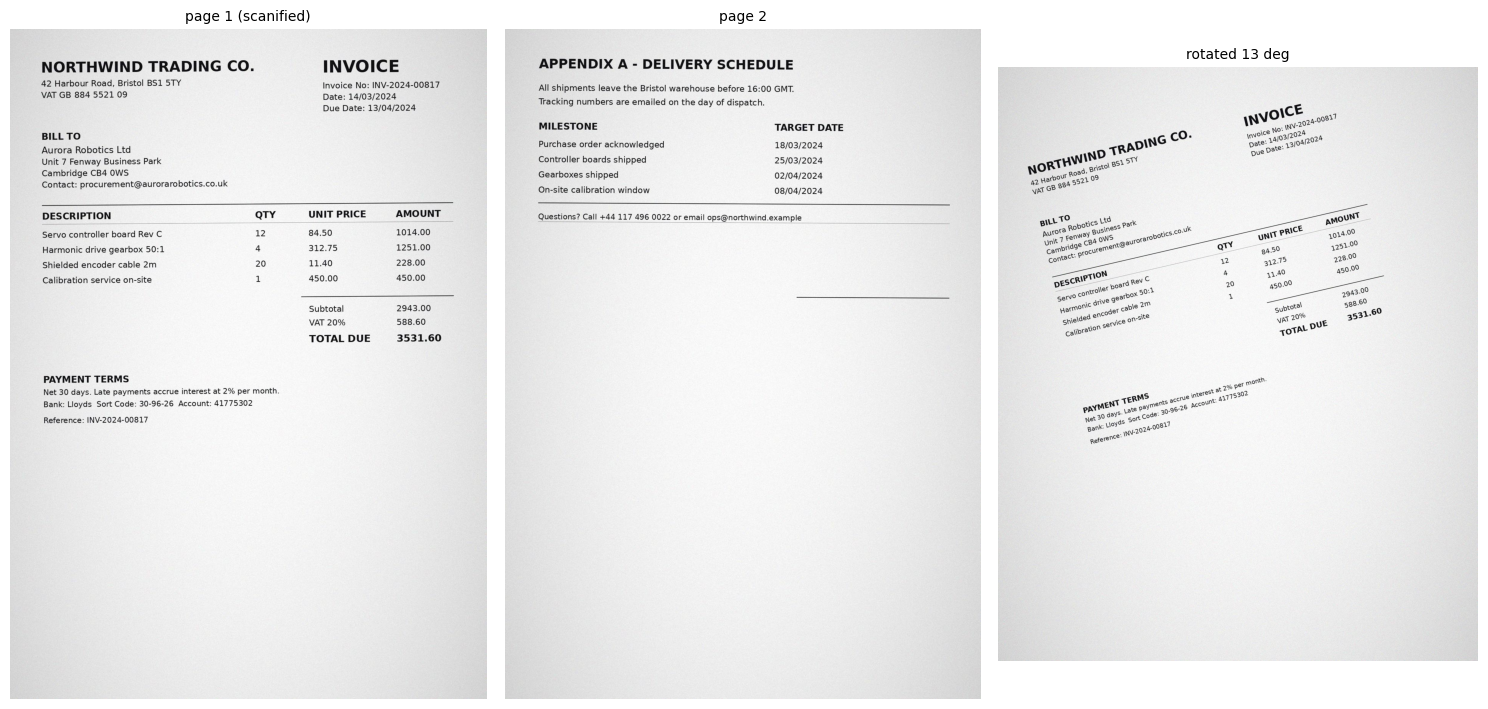

from_images : [(1764, 1254, 3), (1762, 1250, 3)] uint8
from_pdf    : [(1684, 1191, 3), (1684, 1191, 3)]
from_pdf x3 : [(2526, 1786, 3), (2526, 1786, 3)]

Rules of thumb for `scale`:
  * body text should be >= ~10 px tall for the recognition model to be happy
  * scale=2 (default) suits 150-300 dpi scans; bump to 3-4 for dense 8pt text
  * you can also pass raw numpy arrays straight to any predictor:
        predictor([np.asarray(pil_image)])
  * DocumentFile.from_url(...) exists too, but needs the [html] extra



  0%|          | 0/102021912 [00:00<?, ?it/s]

  0%|          | 0/63303144 [00:00<?, ?it/s]


baseline end-to-end: 24.51s for 2 pages (12.25s/page on cpu)
first 90 chars of page 1: 'NORTHWIND TRADING CO.\nINVOICE\n42 Harbour Road, Bristol BS1 5TY\nInvoice No: INV-2024-00817\n'


  0%|          | 0/16991778 [00:00<?, ?it/s]

  0%|          | 0/8420979 [00:00<?, ?it/s]

  0%|          | 0/65814772 [00:00<?, ?it/s]

  0%|          | 0/95457349 [00:00<?, ?it/s]


------------------------------------------------------------------------------
architecture                                    sec/page   #words   word acc
------------------------------------------------------------------------------
db_mobilenet_v3_large + crnn_mobilenet_v3_small      2.67       98     94.1%
fast_base + crnn_vgg16_bn                          11.66      101     99.0%
db_resnet50 + crnn_vgg16_bn                        12.63       98     95.0%
db_resnet50 + parseq                               22.25       98     96.0%
------------------------------------------------------------------------------

Reading the table:
  * detection choice drives RECALL (#words found); recognition drives accuracy
  * mobilenet variants are 5-10x cheaper and lose only a couple of points on
    clean documents — they are usually the right default for bulk pipelines
  * parseq / master are worth it on noisy, handwritten or curved text only
  * these numbers are for ONE synthetic page; always 

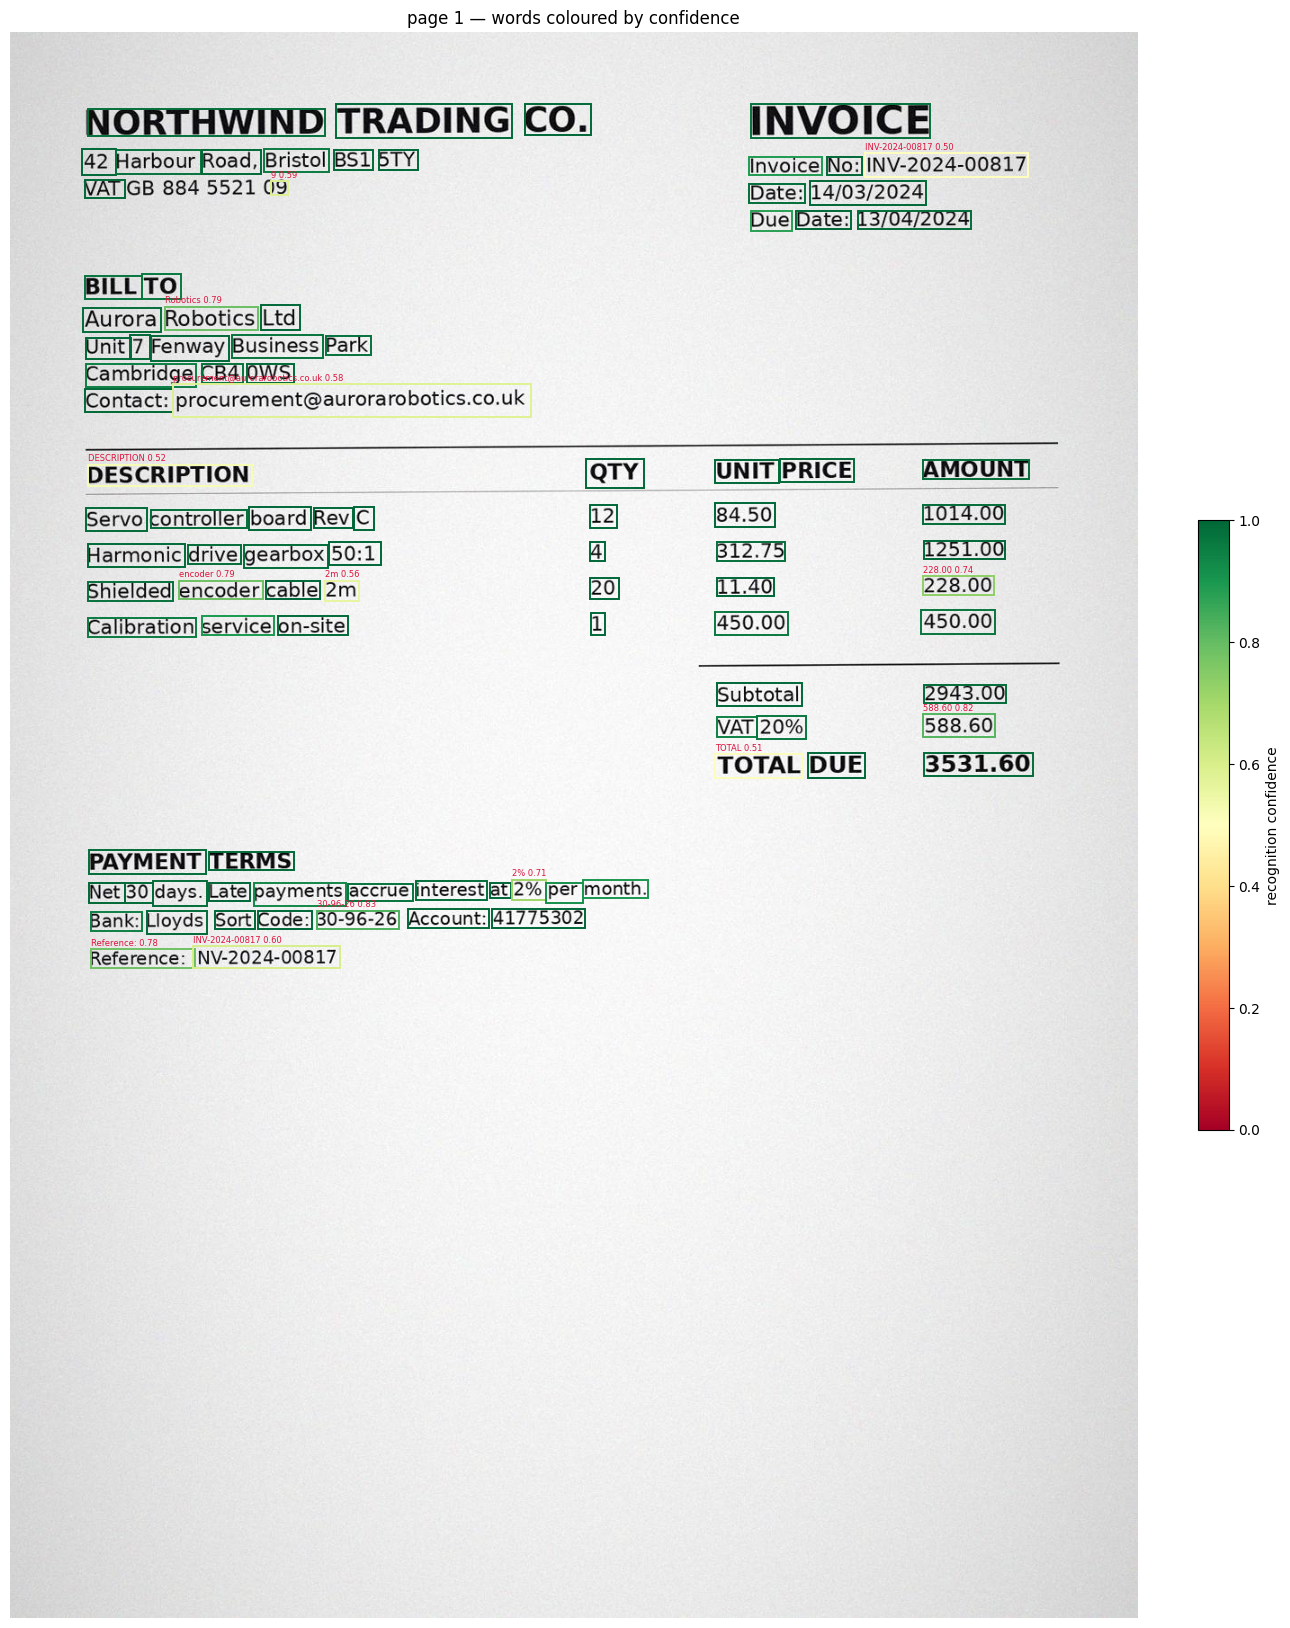

confidence: mean=0.938  p10=0.787  min=0.503   below 0.8: 12 words
detection output: key='words' shape=(98, 5)  (last column is the objectness score)
first 3 boxes (relative):
 [[0.0714 0.5781 0.1634 0.5898 0.4972]
 [0.1621 0.5762 0.2926 0.5898 0.501 ]
 [0.1209 0.5537 0.1744 0.5684 0.6097]]

extracted 98 crops
crop-level predictions (text, confidence):
[('Reference:1', 0.4197574853897095), ('INV-2024-00817', 0.537156879901886), ('Lloyds', 0.9991004467010498), ('Bank:', 0.8551880717277527), ('30-96-26', 0.9848713278770447), ('Code:', 0.9989868998527527), ('Sort', 0.9987418055534363), ('41775302', 0.9916298985481262)]

model vocab (126 chars): 0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!"#$%&'(...

The vocab matters: the default checkpoints ship with a French/Latin vocab.
If your text contains characters outside it, the model literally cannot emit
them and you must fine-tune with a wider `vocab` (see doctr.datasets.VOCABS).



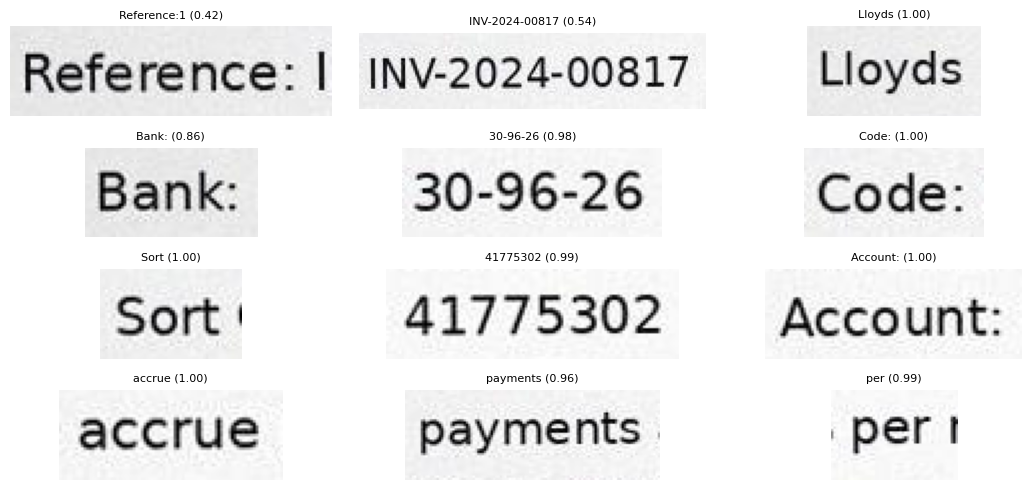

pass 1 (crnn_mobilenet_v3_small): 98 words, 20 below 0.85

before                       conf   after (parseq)               conf
------------------------------------------------------------------------
NORTHWIND                   0.731   NORTHWIND                   1.000
TRADING                     0.810   TRADING                     1.000
Road,                       0.768   Road,                       1.000
Invoice                     0.475   Invoice                     1.000
INV-2024-00817              0.752   INV-2024-00817              1.000
Aurora                      0.727   Aurora                      1.000
Park                        0.585   Park                        1.000
Cambridge                   0.760   Cambridge                   1.000
procurement@aurorarobotics.co.uk  0.776   procuremet@ausanbattuk      0.834  <-- changed
drive                       0.763   drive                       1.000
Shielded                    0.517   Shielded                    1.000
cable    

  0%|          | 0/6233146 [00:00<?, ?it/s]

  0%|          | 0/6233146 [00:00<?, ?it/s]

B polygons               words=  98  acc= 93.1%  15.24s  orientation={'value': None, 'confidence': None}
C straighten first       words= 101  acc= 95.0%  22.16s  orientation={'value': -13, 'confidence': None}
B' polygons -> boxes     words=  98  acc= 93.1%  14.50s  orientation={'value': None, 'confidence': None}


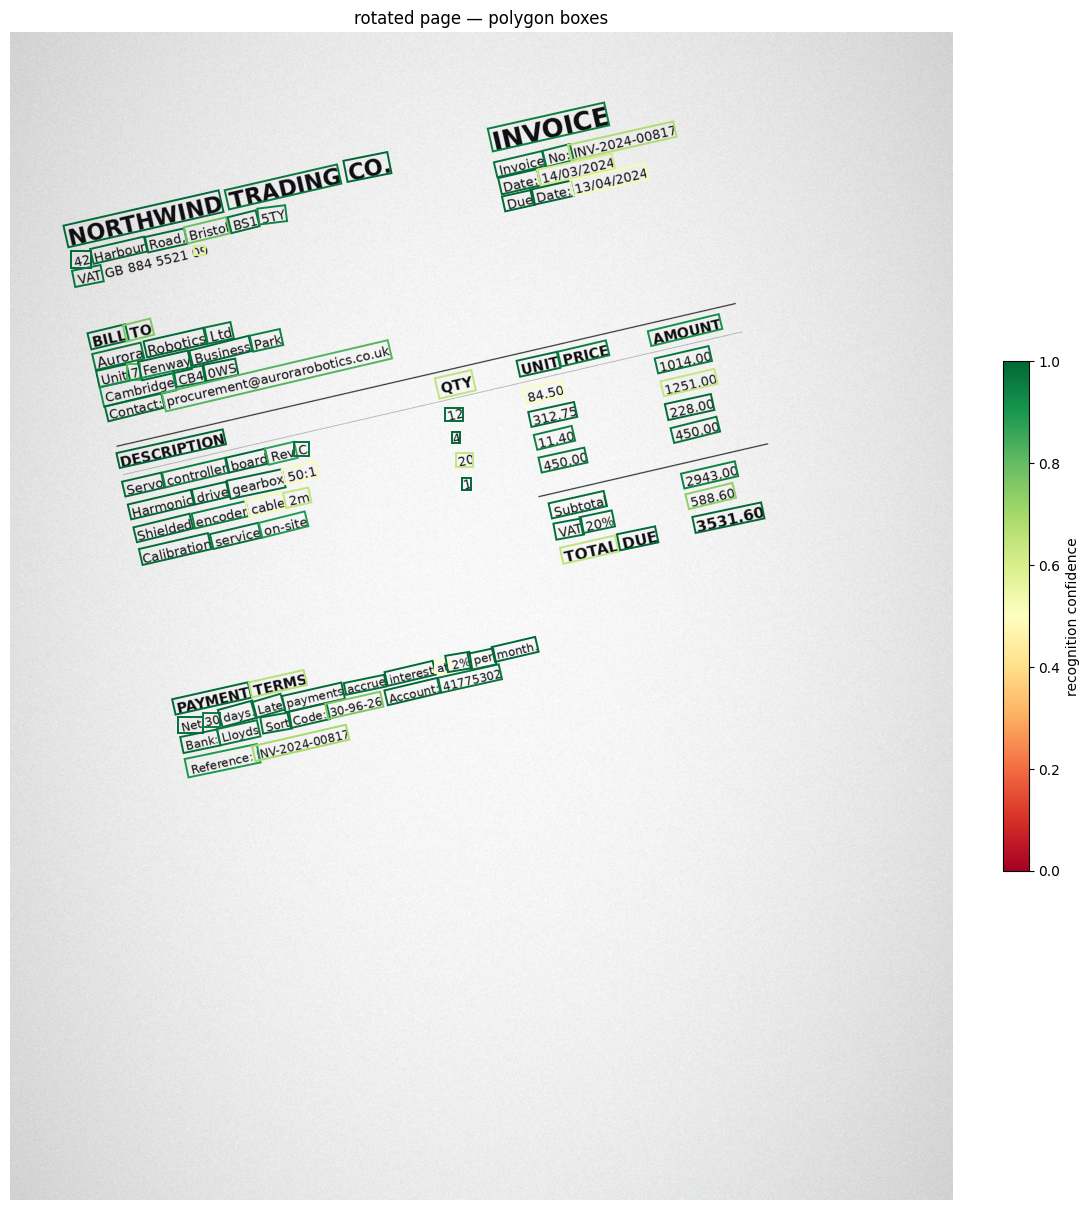


Extra speed switches once you know your data:
  disable_page_orientation=True  skip the 0/90/180/270 page classifier
  disable_crop_orientation=True  skip the per-word orientation classifier
Both only matter when assume_straight_pages=False / straighten_pages=True.

detect_layout not supported by this docTR version (needs >= 1.0) — upgrade with: pip install -U python-doctr
class 'words': 98 predictions
   'NORTHWIND'              conf=0.981 geom=[[0.069, 0.048], [0.279, 0.065]]
   'CO.'                    conf=1.000 geom=[[0.456, 0.045], [0.515, 0.064]]
   'TRADING'                conf=0.995 geom=[[0.288, 0.045], [0.445, 0.066]]
   'INVOICE'                conf=0.977 geom=[[0.657, 0.045], [0.816, 0.066]]
   'BS1'                    conf=0.993 geom=[[0.287, 0.074], [0.321, 0.087]]

To make this genuinely useful, train a detection model with several classes
(references/detection/train_pytorch.py with a multi-class label file), e.g.
classes = ["invoice_number", "total", "date"]. Then KIE

--- render() -------------------------------------------------------
NORTHWIND TRADING CO.
INVOICE
42 Harbour Road, Bristol BS1 5TY
Invoice No: INV-2024-00817
VAT
9
Date: 14/03/2024
Due Date: 13/04/2024
BILL TO
Aurora Robotics Ltd
Unit 7 Fenway Business Park
Cambridge CB4 OWS
Contact: procurement@aurorarobotics.co.uk
DESCRIPTION
QTY
UNIT PRICE
AMOUNT
Servo controller board Rev C
12
84.5 ...

--- export() keys --------------------------------------------------
document: ['pages']
page    : ['page_idx', 'dimensions', 'orientation', 'language', 'blocks']
word    : ['value', 'confidence', 'geometry', 'objectness_score', 'crop_orientation']

--- export_as_xml() (hOCR) ----------------------------------------
<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="en"><head><title>docTR - XML export (hOCR)</title><meta http-equiv="Content-Type" content="text/html; charset=utf-8" /><meta name="ocr-system" content="python-doctr v1.0.1" /><meta name="ocr-capabilities" content="ocr_page ocr_carea o

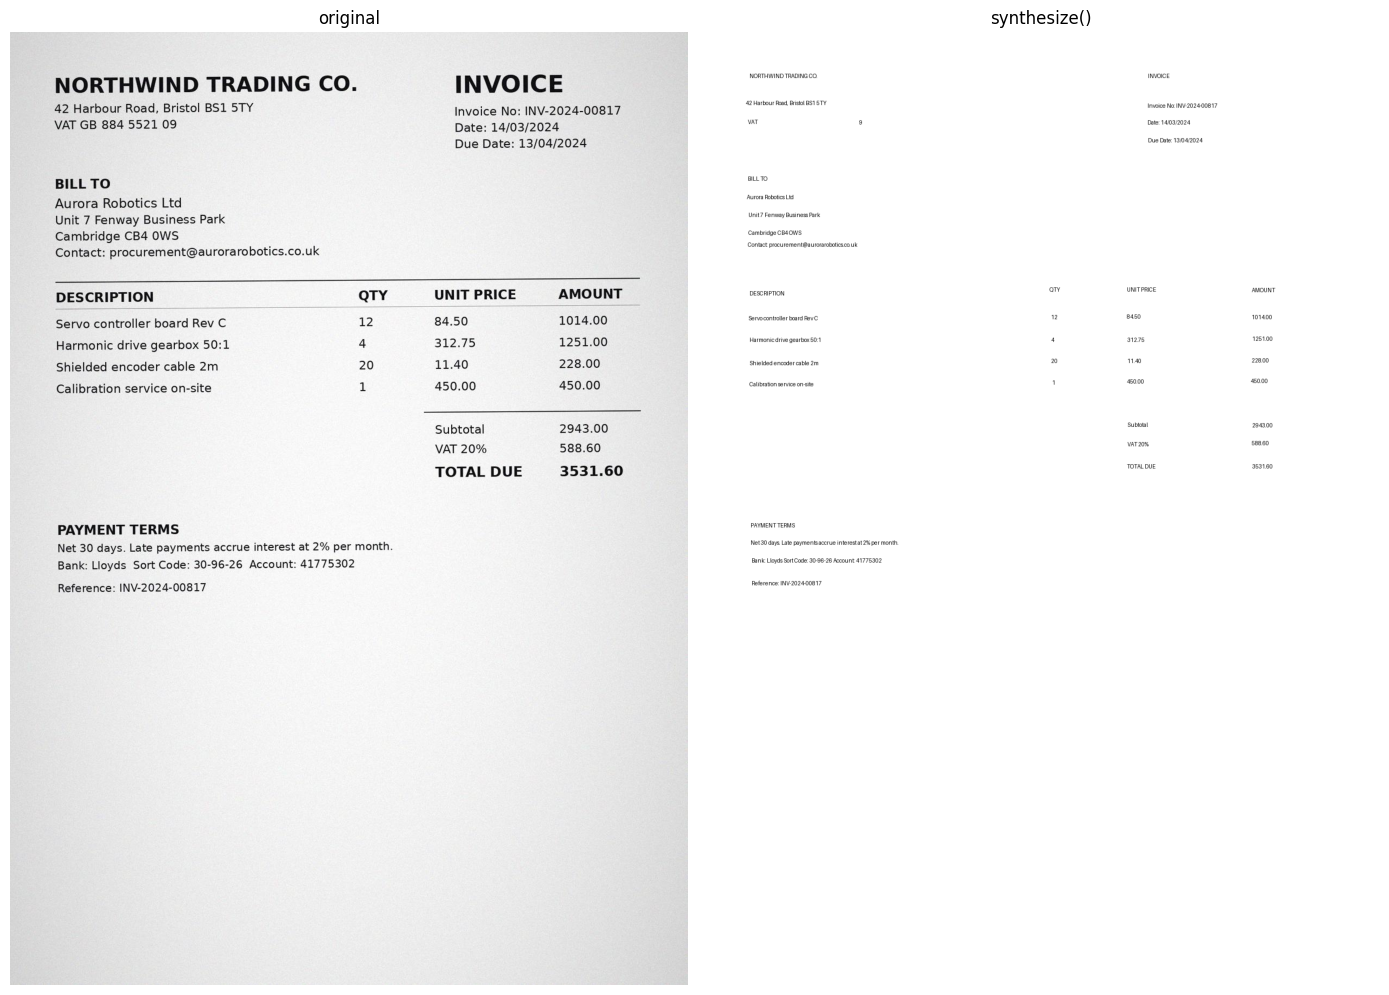

synthesize() re-renders text into the detected boxes. If the reconstruction looks right, geometry AND transcription are both OK.
--- reading order: 21 rows ---
   NORTHWIND TRADING CO. INVOICE
   42 Harbour Road, Bristol BS1 5TY Invoice No: INV-2024-00817
   VAT 9 Date: 14/03/2024
   Due Date: 13/04/2024
   BILL TO
   Aurora Robotics Ltd
   Unit 7 Fenway Business Park
   Cambridge CB4 OWS

--- extracted fields ---
  invoice_no  : INV-2024-00817
  date        : 14/03/2024
  due_date    : 13/04/2024
  vat_id      : None
  total_due   : 3531.60
  subtotal    : 2943.00
  email       : procurement@aurorarobotics.co.uk
  sort_code   : 30-96-26

--- table: 8 columns at x=[0.067, 0.125, 0.207, 0.269, 0.511, 0.625, 0.683, 0.808] ---
  | DESCRIPTION                  |            |            |            | QTY        | UNIT       | PRICE      | AMOUNT    
  | Servo                        | controller | board      | Rev C      | 12         | 84.50      |            | 1014.00   
  | Harmonic      

In [1]:
if CFG["RUN_PDF_EXPORT"]:
    from reportlab.pdfgen import canvas as rl_canvas
    from reportlab.lib.utils import ImageReader

    def make_searchable_pdf(pages_np, doc_result, out_path, dpi=150):
        c = rl_canvas.Canvas(out_path)
        for img_np, page_obj in zip(pages_np, doc_result.pages):
            h_px, w_px = img_np.shape[:2]
            w_pt, h_pt = w_px * 72.0 / dpi, h_px * 72.0 / dpi
            c.setPageSize((w_pt, h_pt))
            c.drawImage(ImageReader(Image.fromarray(img_np)), 0, 0,
                        width=w_pt, height=h_pt)
            c.setFillColorRGB(0, 0, 0)
            for b in page_obj.blocks:
                for l in b.lines:
                    for wd in l.words:
                        if not wd.value.strip():
                            continue
                        x0, y0, x1, y1 = word_rect(wd)
                        bx, by = x0 * w_pt, (1 - y1) * h_pt
                        bw_, bh_ = (x1 - x0) * w_pt, (y1 - y0) * h_pt
                        size = max(bh_ * 0.82, 1.0)
                        t = c.beginText()
                        t.setTextRenderMode(3)
                        t.setFont("Helvetica", size)

                        adv = c.stringWidth(wd.value, "Helvetica", size) or 1.0
                        t.setHorizScale(100.0 * bw_ / adv)
                        t.setTextOrigin(bx, by + bh_ * 0.18)
                        t.textOut(wd.value)
                        c.drawText(t)
            c.showPage()
        c.save()
        return out_path

    out_pdf = make_searchable_pdf(imgs_doc, res,
                                  os.path.join(WORK, "invoice_searchable.pdf"))
    print(f"searchable PDF written: {out_pdf} "
          f"({os.path.getsize(out_pdf)/1024:.0f} KB)")
    print("Open it and Ctrl+F for 'INV-2024-00817' — the scan is unchanged, "
          "but the text is selectable.")
    try:
        from google.colab import files
        print("Run  files.download(out_pdf)  to pull it down from Colab.")
    except ImportError:
        pass


print("""
=============================== PERFORMANCE ==================================
Batch sizes (biggest single lever on GPU):
    ocr_predictor(pretrained=True, det_bs=4, reco_bs=1024)
  Detection is memory-bound (1024x1024 feature maps) so det_bs stays small;
  recognition crops are tiny (32x128) so reco_bs can be huge. On a T4 start at
  det_bs=2, reco_bs=512 and raise reco_bs until you OOM.

Cheap wins, in rough order of payoff:
  1. swap to db_mobilenet_v3_large + crnn_mobilenet_v3_small   (5-10x)
  2. pass ALL pages in one call — predictor(list_of_pages) batches internally
  3. assume_straight_pages=True + disable_*_orientation when data allows
  4. lower the PDF `scale` if your text is already large
  5. half precision:  predictor = predictor.half()  (test accuracy first;
     some post-processors expect float32, so keep a fallback)

Structure knobs (handled by DocumentBuilder):
    resolve_lines=True      group words into lines            (default True)
    resolve_blocks=False    group lines into blocks           (default False)
    paragraph_break=0.035   relative gap that splits paragraphs

============================== FINE-TUNING ===================================
Stock checkpoints are trained on a French/Latin vocab and generic documents.
Fine-tune when you have a custom alphabet, a specialist font, or a domain-
specific layout. In the repo:
    references/detection/train_pytorch.py
    references/recognition/train_pytorch.py
    references/classification/train_pytorch.py   (orientation classifiers)
Recognition wants word crops + labels.json; detection wants full pages with
polygon labels (multi-class supported -> feeds kie_predictor).

Then load your weights:
    from doctr.models import db_resnet50, ocr_predictor
    det = db_resnet50(pretrained=False)
    det.load_state_dict(torch.load("my_det.pt", map_location="cpu"))
    model = ocr_predictor(det_arch=det, reco_arch="crnn_vgg16_bn",
                          pretrained=True)
docTR also pushes/pulls checkpoints from the Hugging Face Hub
(doctr.models.factory: push_to_hf_hub / from_hub).

============================== DEPLOYMENT ====================================
  * FastAPI template in api/ with /detection /recognition /ocr /kie routes
  * GPU-ready Docker images: ghcr.io/mindee/doctr
  * Streamlit demo: streamlit run demo/app.py
  * Live demo: huggingface.co/spaces/mindee/doctr
  * Full docs: mindee.github.io/doctr
==============================================================================
""")

print(f"\nAll artefacts are in {WORK}:")
for f in sorted(os.listdir(WORK)):
    print(f"   {f:<28}{os.path.getsize(os.path.join(WORK, f))/1024:>8.0f} KB")
print("\nDone.")